<a href="https://colab.research.google.com/github/talaA2/IT362-DataScienceProject/blob/main/Extension/BERT_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extension: Fine-tuning BERT for Sentiment Classification

*Added after the course, as an extension of Phase 3.*

The Phase 3 models (Logistic Regression, SVM, Random Forest) represent text with **TF-IDF**, which counts words but ignores their order and context.
**BERT** is a pre-trained language model that reads the whole sentence, so it can pick up context such as negation ("not bad") and tone.

To keep the comparison fair, this notebook uses:
- the **same 3,891 labelled texts** and the **same 80/20 test split** as `Phase 3/Notebooks/Compare_Models_and_Selection.ipynb`
- the **same imbalance handling** (class weights) and the **same main metric** (Macro F1)

**Before running:** in Colab choose **Runtime → Change runtime type → T4 GPU**. The whole notebook takes about 25–30 minutes on a free Colab T4 GPU (3 runs × 4 epochs, about 2 minutes per epoch).

## 1. Setup

In [1]:
import random, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "-", torch.cuda.get_device_name(0) if device.type == "cuda" else "no GPU found")
if device.type != "cuda":
    print("WARNING: no GPU. Training will be very slow. In Colab: Runtime > Change runtime type > T4 GPU")

Device: cuda - Tesla T4


## 2. Load the same data as Phase 3

In [2]:
# Works from the repository and in Colab (reads the copy on GitHub)
DATA_URL = "https://raw.githubusercontent.com/talaA2/IT362-DataScienceProject/main/Phase%203/labeled%20data%20files/"
def data_path(name):
    for folder in [Path("../Phase 3/labeled data files"), Path("Phase 3/labeled data files")]:
        if (folder / name).exists():
            return folder / name
    return DATA_URL + name

youtube = pd.read_csv(data_path("youtube_all_labeled.csv"))
gnews = pd.read_csv(data_path("Gnews_all_labeled.csv"))

# Same combined dataset as every Phase 3 notebook: YouTube first, then GNews
youtube["source"] = "youtube"
gnews["source"] = "gnews"
df = pd.concat([youtube, gnews], ignore_index=True)
df = df.dropna(subset=["text_clean", "label"]).copy()
df["text_clean"] = df["text_clean"].astype(str)
df["label"] = df["label"].astype(int)

print("Final shape:", df.shape)
print(df["label"].value_counts())

Final shape: (3891, 3)
label
-1    2260
 0     839
 1     792
Name: count, dtype: int64


## 3. The same train/test split
The test set is identical to the one used for the Phase 3 models (`random_state=42`, stratified).
BERT needs a small **validation set** to decide when to stop training, so 10% of the *training* data is set aside for that.
The test set is used only once per run, at the very end.

In [3]:
X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# BERT needs labels 0, 1, 2 instead of -1, 0, 1
to_id = {-1: 0, 0: 1, 1: 2}
class_names = ["negative", "neutral", "positive"]

print("Train:", len(X_tr), "| Validation:", len(X_val), "| Test:", len(X_test))

Train: 2800 | Validation: 312 | Test: 779


## 4. Settings
`bert-base-uncased` is the standard BERT model. `MAX_LENGTH` is the number of tokens BERT reads per text: most comments are short, and long news articles are cut to their first part.

In [4]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256
BATCH_SIZE = 16
EPOCHS = 4
LEARNING_RATE = 2e-5
SEEDS = [42, 7, 123]      # 3 runs with different random seeds, reported as mean ± std

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

lengths = [len(tokenizer.encode(t, truncation=False)) for t in X_train.sample(500, random_state=0)]
print(f"Share of training texts that fit in {MAX_LENGTH} tokens: {np.mean(np.array(lengths) <= MAX_LENGTH):.1%}")

Share of training texts that fit in 256 tokens: 99.0%


In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(list(texts), truncation=True, max_length=MAX_LENGTH, padding="max_length", return_tensors="pt")
        self.labels = torch.tensor([to_id[v] for v in labels])
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return {"input_ids": self.enc["input_ids"][i], "attention_mask": self.enc["attention_mask"][i], "labels": self.labels[i]}

train_ds, val_ds, test_ds = TextDataset(X_tr, y_tr), TextDataset(X_val, y_val), TextDataset(X_test, y_test)

# Class weights, same idea as class_weight="balanced" in the Phase 3 models
weights = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=train_ds.labels.numpy())
loss_fn = torch.nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float).to(device))
print("Class weights (negative, neutral, positive):", np.round(weights, 2))

Class weights (negative, neutral, positive): [0.57 1.55 1.64]


## 5. Train and evaluate

In [6]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

@torch.no_grad()
def predict(model, dataset):
    model.eval()
    preds = []
    for batch in DataLoader(dataset, batch_size=64):
        logits = model(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device)).logits
        preds.append(logits.argmax(dim=1).cpu())
    return torch.cat(preds).numpy()

def train_one_run(seed):
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(seed))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    total_steps = len(loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

    best_f1, best_state, best_epoch = -1, None, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        start, running = time.time(), 0.0
        for batch in loader:
            optimizer.zero_grad()
            logits = model(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device)).logits
            loss = loss_fn(logits, batch["labels"].to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            running += loss.item()
        val_f1 = f1_score(val_ds.labels.numpy(), predict(model, val_ds), average="macro")
        print(f"  seed {seed} | epoch {epoch} | train loss {running / len(loader):.3f} | validation Macro F1 {val_f1:.3f} | {time.time() - start:.0f}s")
        if val_f1 > best_f1:   # keep the epoch that does best on VALIDATION (never on test)
            best_f1, best_epoch = val_f1, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    test_pred = predict(model, test_ds)
    del model; torch.cuda.empty_cache()
    return best_epoch, test_pred

runs = []
for seed in SEEDS:
    print(f"Run with seed {seed}")
    best_epoch, test_pred = train_one_run(seed)
    y_true = test_ds.labels.numpy()
    runs.append({"seed": seed, "best_epoch": best_epoch, "pred": test_pred,
                 "macro_f1": f1_score(y_true, test_pred, average="macro"),
                 "accuracy": accuracy_score(y_true, test_pred)})
    print(f"  -> test Macro F1 {runs[-1]['macro_f1']:.3f} | test accuracy {runs[-1]['accuracy']:.3f}\n")

Run with seed 42


[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  seed 42 | epoch 1 | train loss 0.964 | validation Macro F1 0.596 | 116s
  seed 42 | epoch 2 | train loss 0.655 | validation Macro F1 0.651 | 128s
  seed 42 | epoch 3 | train loss 0.423 | validation Macro F1 0.697 | 129s
  seed 42 | epoch 4 | train loss 0.283 | validation Macro F1 0.711 | 129s
  -> test Macro F1 0.702 | test accuracy 0.738

Run with seed 7


[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  seed 7 | epoch 1 | train loss 0.955 | validation Macro F1 0.645 | 129s
  seed 7 | epoch 2 | train loss 0.606 | validation Macro F1 0.682 | 129s
  seed 7 | epoch 3 | train loss 0.368 | validation Macro F1 0.669 | 129s
  seed 7 | epoch 4 | train loss 0.239 | validation Macro F1 0.688 | 129s
  -> test Macro F1 0.719 | test accuracy 0.765

Run with seed 123


[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  seed 123 | epoch 1 | train loss 0.960 | validation Macro F1 0.571 | 129s
  seed 123 | epoch 2 | train loss 0.644 | validation Macro F1 0.680 | 129s
  seed 123 | epoch 3 | train loss 0.413 | validation Macro F1 0.701 | 130s
  seed 123 | epoch 4 | train loss 0.289 | validation Macro F1 0.689 | 129s
  -> test Macro F1 0.719 | test accuracy 0.759



## 6. Results

In [7]:
per_run = pd.DataFrame([{k: v for k, v in r.items() if k != "pred"} for r in runs]).round(3)
print(per_run.to_string(index=False))

bert_f1 = per_run["macro_f1"].mean(); bert_f1_std = per_run["macro_f1"].std(ddof=0)
bert_acc = per_run["accuracy"].mean()
print(f"\nBERT on the test set (mean ± std over {len(SEEDS)} runs): Macro F1 {bert_f1:.3f} ± {bert_f1_std:.3f} | accuracy {bert_acc:.3f}")

 seed  best_epoch  macro_f1  accuracy
   42           4     0.702     0.738
    7           4     0.719     0.765
  123           3     0.719     0.759

BERT on the test set (mean ± std over 3 runs): Macro F1 0.713 ± 0.008 | accuracy 0.754


For comparison, the two best Phase 3 models are re-trained here on exactly the same training data and scored on the same test set:

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

def tfidf():
    return TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)

rows = []
for name, clf in [("SVM (LinearSVC)", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
                  ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))]:
    pred = make_pipeline(tfidf(), clf).fit(X_train, y_train).predict(X_test)
    rows.append({"Model": name, "Macro F1": f1_score(y_test, pred, average="macro"), "Accuracy": accuracy_score(y_test, pred),
                 **dict(zip([f"F1 {c}" for c in class_names], f1_score(y_test, pred, average=None, labels=[-1, 0, 1])))})

y_true = test_ds.labels.numpy()
per_class = np.mean([f1_score(y_true, r["pred"], average=None, labels=[0, 1, 2]) for r in runs], axis=0)
rows.append({"Model": f"BERT (mean of {len(SEEDS)} runs)", "Macro F1": bert_f1, "Accuracy": bert_acc,
             **dict(zip([f"F1 {c}" for c in class_names], per_class))})

comparison = pd.DataFrame(rows).sort_values("Macro F1", ascending=False).round(3)
comparison.reset_index(drop=True)

,Model,Macro F1,Accuracy,F1 negative,F1 neutral,F1 positive
0,BERT (mean of 3 runs),0.713,0.754,0.821,0.706,0.612
1,Logistic Regression,0.669,0.711,0.790,0.608,0.610
2,SVM (LinearSVC),0.669,0.723,0.805,0.595,0.608


Run with seed 7 (closest to the average):

              precision    recall  f1-score   support

    negative      0.817     0.852     0.834       452
     neutral      0.703     0.720     0.712       168
    positive      0.662     0.566     0.610       159

    accuracy                          0.765       779
   macro avg      0.728     0.713     0.719       779
weighted avg      0.761     0.765     0.762       779



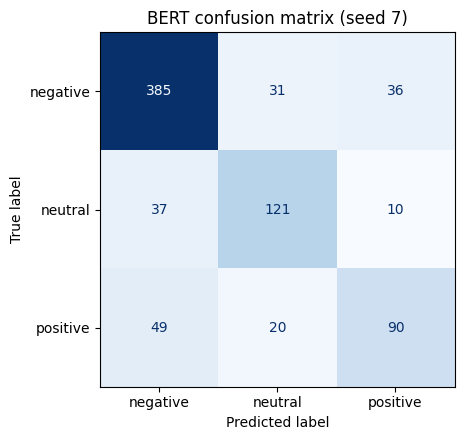

In [9]:
# Detailed report and confusion matrix for the run closest to the average
typical = min(runs, key=lambda r: abs(r["macro_f1"] - bert_f1))
print(f"Run with seed {typical['seed']} (closest to the average):\n")
print(classification_report(y_true, typical["pred"], target_names=class_names, digits=3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_true, typical["pred"], display_labels=class_names, cmap="Blues", colorbar=False, ax=ax)
ax.set_title(f"BERT confusion matrix (seed {typical['seed']})")
ax.grid(False)
plt.tight_layout()
plt.show()

In [10]:
# Summary to copy into the README
svm = comparison.set_index("Model").loc["SVM (LinearSVC)"]
print("=" * 70)
print(f"BERT:  Macro F1 {bert_f1:.3f} ± {bert_f1_std:.3f}  | accuracy {bert_acc:.1%}   ({len(SEEDS)} runs, same test set)")
print(f"SVM:   Macro F1 {svm['Macro F1']:.3f}          | accuracy {svm['Accuracy']:.1%}")
print(f"Difference in Macro F1: {bert_f1 - svm['Macro F1']:+.3f}")
print("=" * 70)


BERT:  Macro F1 0.713 ± 0.008  | accuracy 75.4%   (3 runs, same test set)
SVM:   Macro F1 0.669          | accuracy 72.3%
Difference in Macro F1: +0.044


## 7. Conclusion

**Fine-tuned BERT clearly beats the best classical model on the same test set.**

| Model | Macro F1 | Accuracy | F1 negative | F1 neutral | F1 positive |
|---|:---:|:---:|:---:|:---:|:---:|
| **BERT** (mean of 3 runs) | **0.713 ± 0.008** | **75.4%** | **0.821** | **0.706** | **0.612** |
| SVM (best Phase 3 model) | 0.669 | 72.3% | 0.805 | 0.595 | 0.608 |

- **+0.044 Macro F1** over SVM, and **every one of the 3 runs** beat it (0.702, 0.719, 0.719), so the gain is not luck from one run.
- **Most of the gain is on neutral texts** (F1 0.595 → 0.706). Reading words in context helps separate neutral comments from negative ones, which TF-IDF word counts struggle with.
- **Positive texts stay the hardest class** (F1 ≈ 0.61 for both models): many positive comments still share vocabulary with negative ones.
- BERT was trained on 90% of the training data (the rest was used for validation), while SVM used all of it, so this comparison, if anything, slightly favours SVM.
- **Trade-off:** BERT needs a GPU and about 2 minutes per training epoch, while SVM trains in seconds on a laptop.

**Possible next steps:** more training epochs (validation scores were still rising at epoch 4 in two runs), a model pre-trained on social-media text such as BERTweet, and labelling more positive examples.